In [3]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

import re #Regular Expression library to remove all html tags

import nltk #Natural language toolkit to remove stop words
# nltk.download('stopwords')
from nltk.corpus import stopwords

from nltk.stem.porter import PorterStemmer

#convert to tabular data
from sklearn.feature_extraction.text import CountVectorizer

from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import MultinomialNB, GaussianNB, BernoulliNB

from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score, precision_score, recall_score, f1_score

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('sentiment.csv')

In [5]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [6]:
df.shape

(50000, 2)

**Plots**

Text(0, 0.5, 'Number of reviews')

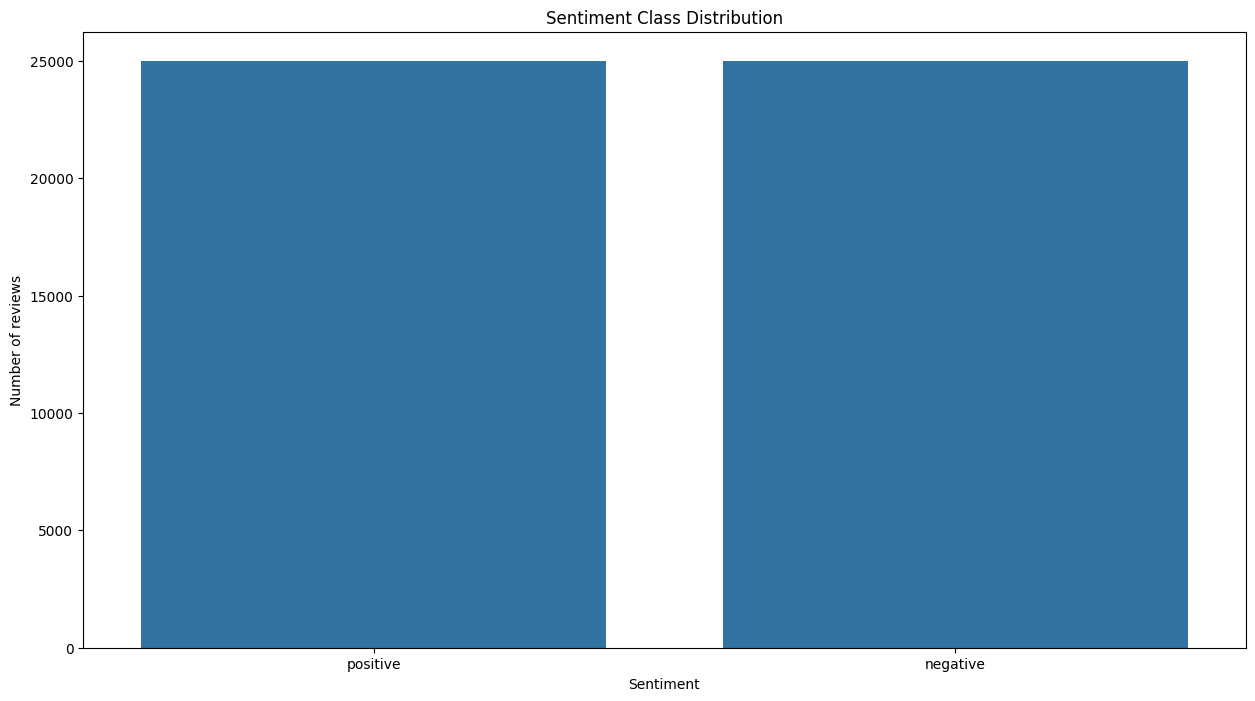

In [7]:
#Class Distribution Bar Chart    (Balanced Data)

plt.figure(figsize=(15,8))

sns.countplot(data=df, x="sentiment")

plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel('Number of reviews')

In [8]:
#One Review

df['review'][0]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

**Text Cleaning**

1) Sample 10000 rows
2) Remove HTML Tags
3) Remove Special Characters
4) Converting Everything to lower case
5) Removing Stop words
6) Stemming (e.g play, played, playing -> play)

In [9]:
df = df.sample(10000)

In [10]:
df.shape

(10000, 2)

In [11]:
df.isnull().sum() #No missing value

review       0
sentiment    0
dtype: int64

In [12]:
df.dtypes.value_counts()

object    2
Name: count, dtype: int64

In [13]:
#Encoding label

encoder = LabelEncoder()
df['sentiment'] = encoder.fit_transform(df['sentiment'])

In [14]:
df.dtypes.value_counts()

object    1
int64     1
Name: count, dtype: int64

In [15]:
#Removing HTML tags

def clean_html(text):
    clean = re.compile('<.*?>')
    return re.sub(clean, '', text)

In [16]:
df['review'] = df['review'].apply(clean_html)

In [17]:
df.head()

,review,sentiment
23413,"To be fair, I expected car chases in this film...",1
11665,The premise of the story is simple: An old man...,1
29752,"Even thought I'm not the biggest of Cher fans,...",0
37920,Sandler is amazing again... I have already bec...,1
40107,"This isn't the comedic Robin Williams, nor is ...",1


In [18]:
#Converting text to lower case

def covert_lower(text):
    return text.lower()

In [19]:
df['review'] = df['review'].apply(covert_lower)

In [20]:
df.head()

,review,sentiment
23413,"to be fair, i expected car chases in this film...",1
11665,the premise of the story is simple: an old man...,1
29752,"even thought i'm not the biggest of cher fans,...",0
37920,sandler is amazing again... i have already bec...,1
40107,"this isn't the comedic robin williams, nor is ...",1


In [21]:
 #Remove special characters

def remove_special(text):
    x = ''

    for i in text:
        if i.isalnum(): #alpha numeric or not ?
            x+=i
        else:
            x+=' '
    return x

In [22]:
remove_special("testing@ removal%#functi@on")

'testing  removal  functi on'

In [23]:
#Remove the Stopwords
stop_words = set(stopwords.words('english'))

# len(stopwords.words('english'))
#stopwords.words('english')

In [24]:
def remove_stopwords(text):
    x = []
    for i in text.split():
        if i not in stop_words:
            x.append(i)
    return x

In [25]:
 df['review'] = df['review'].apply(remove_stopwords)

In [26]:
df.head()

,review,sentiment
23413,"[fair,, expected, car, chases, film., really, ...",1
11665,"[premise, story, simple:, old, man, living, al...",1
29752,"[even, thought, biggest, cher, fans,, movie, c...",0
37920,"[sandler, amazing, again..., already, become, ...",1
40107,"[comedic, robin, williams,, quirky/insane, rob...",1


In [27]:
#Stemming

ps = PorterStemmer() #convert to base form, loving to love

In [28]:
def stem_words(text):
    y = []
    for i in text:
        y.append(ps.stem(i))
    return y

In [29]:
stem_words(['playing', 'played', 'ball'])

['play', 'play', 'ball']

In [30]:
 df['review'] = df['review'].apply(stem_words)

In [31]:
df.head()

,review,sentiment
23413,"[fair,, expect, car, chase, film., realli, one...",1
11665,"[premis, stori, simple:, old, man, live, alon,...",1
29752,"[even, thought, biggest, cher, fans,, movi, cr...",0
37920,"[sandler, amaz, again..., alreadi, becom, sand...",1
40107,"[comed, robin, williams,, quirky/insan, robin,...",1


In [32]:
def join_back(list_input):
    return " ".join(list_input)

In [33]:
 df['review'] = df['review'].apply(join_back)

In [34]:
df.head()

,review,sentiment
23413,"fair, expect car chase film. realli one, apart...",1
11665,premis stori simple: old man live alon wood ac...,1
29752,"even thought biggest cher fans, movi crown ach...",0
37920,sandler amaz again... alreadi becom sandler fa...,1
40107,"comed robin williams, quirky/insan robin willi...",1


In [35]:
#Convert text to tabular data

cv = CountVectorizer()

In [36]:
X = cv.fit_transform(df['review']).toarray() #Convert to numpy array

In [37]:
X.shape

(10000, 49450)

In [38]:
X[0]

array([0, 0, 0, ..., 0, 0, 0], shape=(49450,))

In [39]:
y = df.iloc[:,-1].values #convert pd to numpy array
#:    → all rows
#-1   → last column

In [40]:
y

array([1, 1, 0, ..., 0, 0, 0], shape=(10000,))

In [41]:
y.shape

(10000,)

**Data now Ready**

**Splitting Data**

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

In [43]:
X_train.shape

(8000, 49450)

In [44]:
X_test.shape

(2000, 49450)

In [45]:
y_train.shape

(8000,)

In [46]:
y_test.shape

(2000,)

**Training Models**

In [47]:
model1 = MultinomialNB()
model2 = GaussianNB()
model3 = BernoulliNB()

In [48]:
model1.fit(X_train, y_train)
model2.fit(X_train, y_train)
model3.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,binarize,0.0
,fit_prior,True
,class_prior,None


**Testing Models**

In [49]:
y_pred1 = model1.predict(X_test)
y_pred2 = model2.predict(X_test)
y_pred3 = model3.predict(X_test)

**Accuracy**

How many reviews did the model classify correctly overall?

In [50]:
print(f"Multinomial NB:  {(accuracy_score(y_test, y_pred1))*100}%")
print(f"Guassian NB:  {(accuracy_score(y_test, y_pred2))*100}%")
print(f"Bernoulli NB:  {(accuracy_score(y_test, y_pred3))*100}%")

Multinomial NB:  84.1%
Guassian NB:  64.5%
Bernoulli NB:  84.95%


**Precision**

When the model says "Positive", how often is it actually positive?

How reliable positive/negative predictions

In [51]:
print(f"Precision: {(precision_score(y_test, y_pred1)*100):.2f}%")

Precision: 86.12%


**Recall**

Of all the actually positive reviews, how many did my model correctly identify as positive?

How many actual positives/negatives are detected

In [52]:
print(f"Recall: {(recall_score(y_test, y_pred1)*100):.2f}%")

Recall: 81.30%


**F1-score**


F1-score tells you how well your model simultaneously avoids wrong predictions (precision) and avoids missing actual examples of a class (recall).

For your sentiment model, a high F1 means the model is both good at identifying a sentiment and reliable when it predicts that sentiment.

In [53]:
print(f"F1-score: {(f1_score(y_test, y_pred1)*100):.2f}%")

F1-score: 83.64%


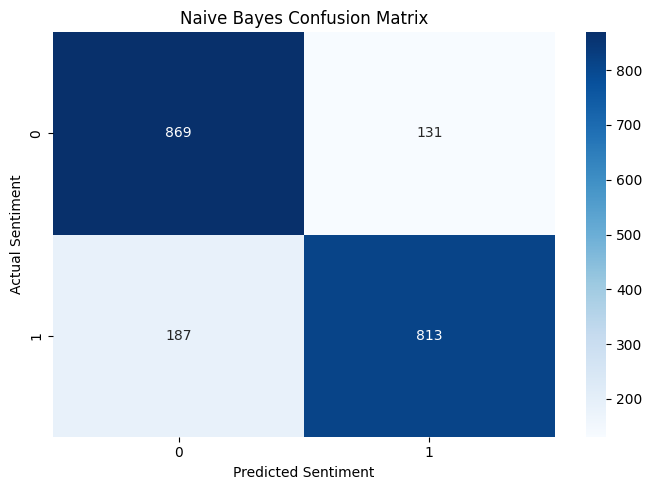

In [54]:
#Confusion Matrix for Best Model -> Multinomial NB

cm = confusion_matrix(y_test, y_pred1)


plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model1.classes_,
    yticklabels=model1.classes_
)

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.tight_layout()
plt.show()

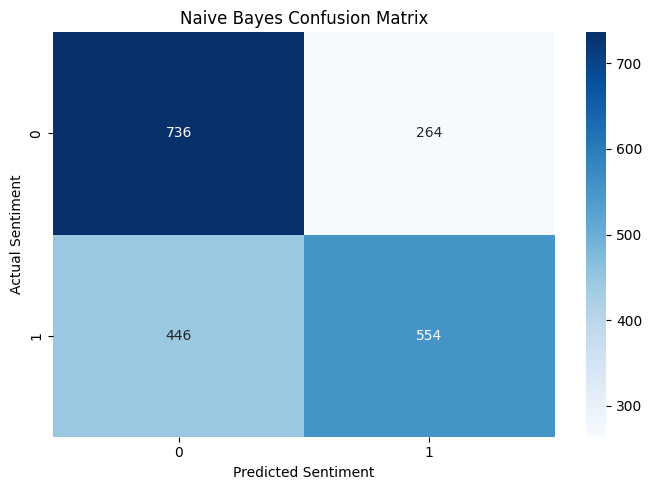

In [55]:
#Confusion Matrix for Worst Model -> Guassian NB

cm = confusion_matrix(y_test, y_pred2)


plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model2.classes_,
    yticklabels=model2.classes_
)

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.tight_layout()
plt.show()

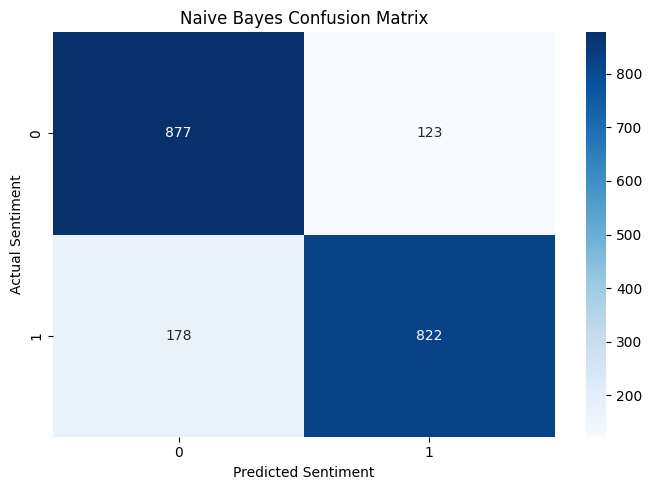

In [56]:
#Confusion Matrix for -> Bernoulli NB

cm = confusion_matrix(y_test, y_pred3)


plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model3.classes_,
    yticklabels=model3.classes_
)

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.tight_layout()
plt.show()

**ROC = Receiver Operating Characteristic curve:** It evaluates how well your model can distinguish between two classes.

**Y-axis = True Positive Rate (TPR) / Sensitivity / Recall:** Of all the actually positive reviews, how many did my model correctly identify as positive?

**X-axis = False Positive Rate (FPR):** Of all the actually negative reviews, how many did my model incorrectly call positive?

**AUC = Area Under the Curve.**

**AUC = 1.0:** Excellent.

**AUC ≈ 0.5:** Basically random guessing.

**AUC between 0.5 and 1:** Generally, higher is better.

ROC takes the Positive probability scores that NB produced

           NAIVE BAYES
                ↓
       Probability scores
                ↓
              ROC
                ↓
       Measures separation
                ↓
              AUC
                ↓
     Overall discrimination score

ROC-AUC: 0.9094709999999999


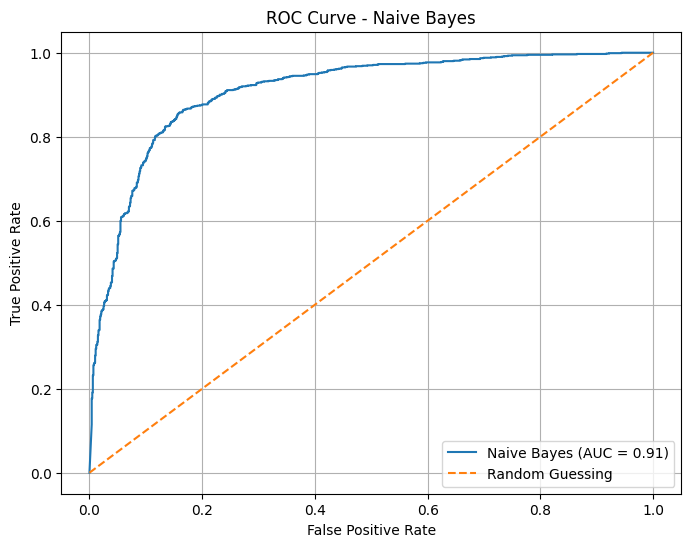

In [57]:
y_test_prob = model1.predict_proba(X_test)[:, 1] #getting Positive prob scores only

fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)

auc_score = roc_auc_score(y_test, y_test_prob)

print("ROC-AUC:", auc_score)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Naive Bayes (AUC = {auc_score:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Guessing"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Naive Bayes")
plt.legend()
plt.grid()
plt.show()

**Bar chart of the top 15 most “informative” features:** Two horizontal bar charts showing which words are most strongly associated with the positive and negative sentiment classes in your Naive Bayes model.


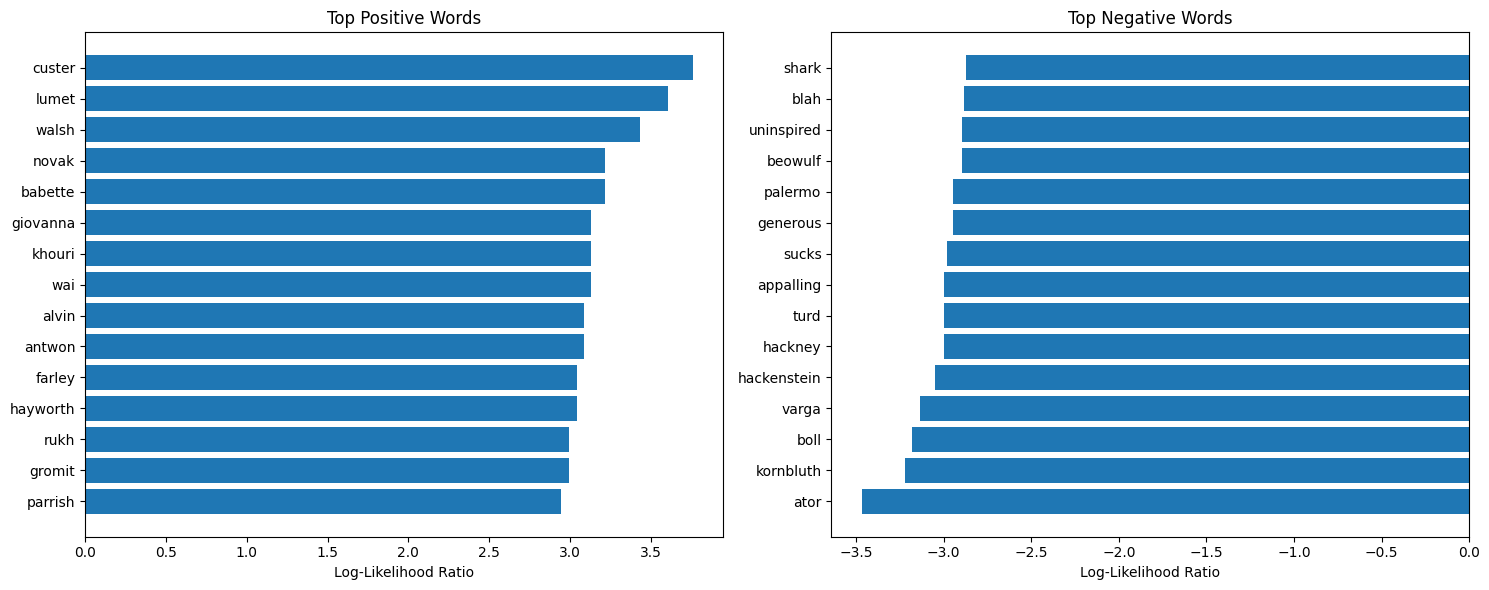

In [59]:

feature_names = cv.get_feature_names_out() #names of all the features (all unique words)

log_prob = model1.feature_log_prob_ #NB calculates prob for each feature P("good"|neg) P("good"|pos)  -> two columns

log_ratio = log_prob[1] - log_prob[0] #pos - neg = + or - sentiment more 
#Positive log ratio → positive word
#Negative log ratio → negative word

top_positive = log_ratio.argsort()[-15:] #sort smallest to largest, take last 15 elements
top_negative = log_ratio.argsort()[:15] #sort smallest to largest, take first 15 elements

#After colon ,nothing means -> Continue until the end.
#When nothing is written before the colon, Python assumes: Start from the beginning.

positive_words = feature_names[top_positive]
positive_scores = log_ratio[top_positive]

negative_words = feature_names[top_negative]
negative_scores = log_ratio[top_negative]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].barh(
    positive_words, #y
    positive_scores #x
)

axes[0].set_title("Top Positive Words")
axes[0].set_xlabel("Log-Likelihood Ratio")

axes[1].barh(
    negative_words,
    negative_scores
)

axes[1].set_title("Top Negative Words")
axes[1].set_xlabel("Log-Likelihood Ratio")

plt.tight_layout()
plt.show()